Defaulting to user installation because normal site-packages is not writeable
Current working directory: /Users/edaonay/Desktop/DI501_EdaOnay_InterimProject_2739415/DI501_EdaOnay_InterimPhase_2739415/notebooks
Project root: /Users/edaonay/Desktop/DI501_EdaOnay_InterimProject_2739415/DI501_EdaOnay_InterimPhase_2739415
Data path: /Users/edaonay/Desktop/DI501_EdaOnay_InterimProject_2739415/DI501_EdaOnay_InterimPhase_2739415/data
tracks shape: (101939, 32)
albums shape: (75511, 16)
artists shape: (56129, 9)
lyrics shape: (94954, 8)

Column checks
track_id in tracks: True
track_id in albums: True
track_id in artists: True
track_id in lyrics: True

Merged shape: (101939, 21)
\STEP 3 OF INTERIM REPORT: DATA QUALITY CHECKS

Missing value percentage (top 20)
followers              55.961899
artist_popularity      55.961899
decade                 31.713083
decade_num             31.713083
release_year           31.713083
release_date           31.713083
total_tracks           25.934137
album_typ

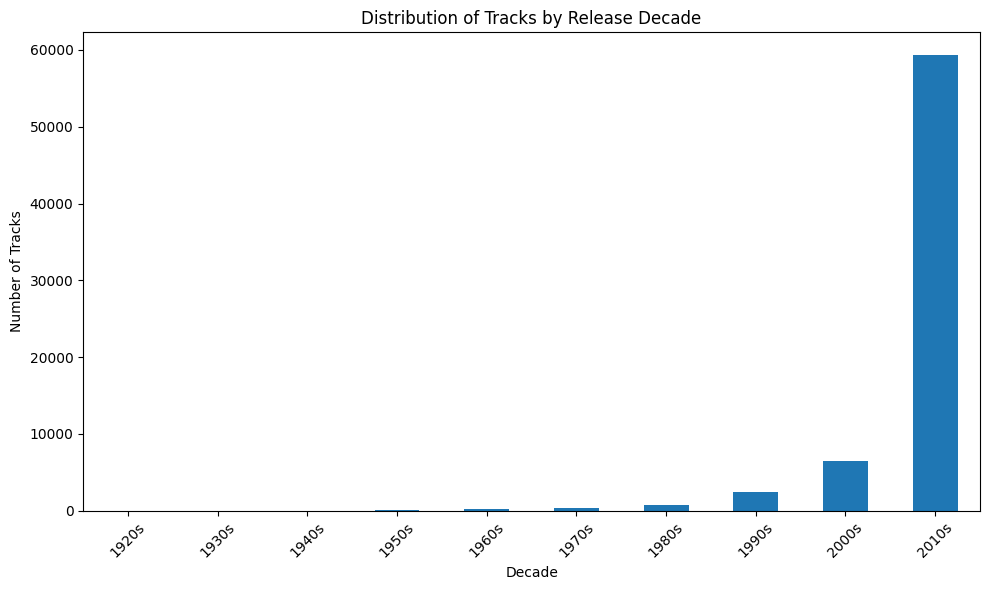

<Figure size 800x600 with 0 Axes>

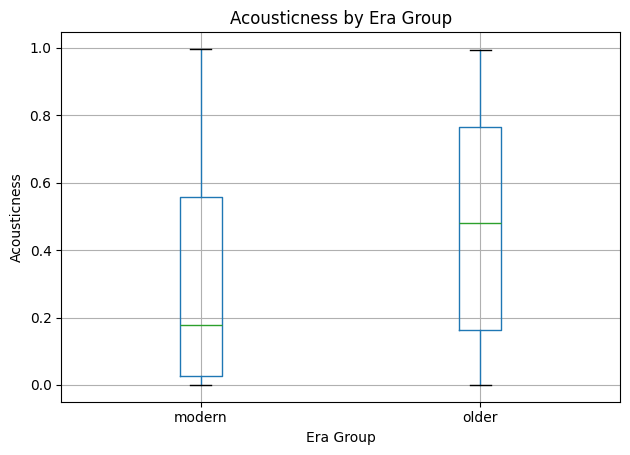

<Figure size 800x600 with 0 Axes>

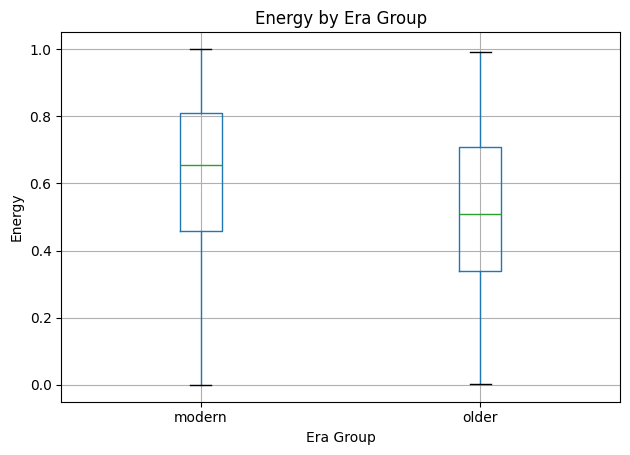


STEP 4: ML PREPARATION & NAIVE BASELINE

ML dataset shape before dropping missing feature rows: (69611, 19)
ML dataset shape after dropping missing feature rows: (28922, 19)

Decade/era distribution before rare-class filtering
decade
1920s        1
1950s       13
1960s       59
1970s      109
1980s      241
1990s      881
2000s     2564
2010s    25054
Name: count, dtype: int64

Decade/era distribution after filtering classes with < 10 samplesß
decade
1950s       13
1960s       59
1970s      109
1980s      241
1990s      881
2000s     2564
2010s    25054
Name: count, dtype: int64

Naive baseline results
              Metric  Naive Baseline Score
0           Accuracy              0.866206
1           Macro-F1              0.132615
2  Balanced Accuracy              0.142857

Save files/outputs:
- descriptive_statistics_for_interim_edaonay_2739415.csv
- older_vs_modern_summary_for_interim_edaonay_2739415.csv
- figure_decade_distribution_for_interim_edaonay_2739415.pdf
- figure_acousticnes

In [3]:
import sys
!{sys.executable} -m pip install scikit-learn
import pandas as pdeda
import numpy as npeda
import os
import matplotlib.pyplot as plteda
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score
from sklearn.dummy import DummyClassifier
#i used sklearn as Volga said in our latest lab session

#read csv files

cwd = Path.cwd()

project_root = cwd
while not (project_root / "data").exists() and project_root != project_root.parent:
    project_root = project_root.parent

if not (project_root / "data").exists():
    raise FileNotFoundError("Project root with 'data' folder could not be found.")

data_path = project_root / "data"
figures_path = project_root / "figures"
csv_output_path = project_root / "generated csv files"

# klasörler yoksa oluştur
figures_path.mkdir(exist_ok=True)
csv_output_path.mkdir(exist_ok=True)

print("Current working directory:", cwd)
print("Project root:", project_root)
print("Data path:", data_path)

tracks = pdeda.read_csv(data_path / "spotify_tracks.csv")
albums = pdeda.read_csv(data_path / "spotify_albums.csv")
artists = pdeda.read_csv(data_path / "spotify_artists.csv")
lyrics = pdeda.read_csv(data_path / "lyrics_features.csv")

print("tracks shape:", tracks.shape)
print("albums shape:", albums.shape)
print("artists shape:", artists.shape)
print("lyrics shape:", lyrics.shape)

#cleaning

def drop_unnamed(df):
    return df.loc[:, ~df.columns.str.contains("^Unnamed")]

tracks = drop_unnamed(tracks)
albums = drop_unnamed(albums)
artists = drop_unnamed(artists)
lyrics = drop_unnamed(lyrics)

# change id columns in spotify_tracks table to track_id 
if "id" in tracks.columns and "track_id" not in tracks.columns:
    tracks = tracks.rename(columns={"id": "track_id"})

print("\nColumn checks")
print("track_id in tracks:", "track_id" in tracks.columns)
print("track_id in albums:", "track_id" in albums.columns)
print("track_id in artists:", "track_id" in artists.columns)
print("track_id in lyrics:", "track_id" in lyrics.columns)


#degrade the artist table to track-level
artist_agg = artists.groupby("track_id", as_index=False).agg({
    "artist_popularity": "max",
    "followers": "max"
})

#picking the necessary columns

track_keep = [
    "track_id",
    "acousticness",
    "danceability",
    "energy",
    "instrumentalness",
    "liveness",
    "speechiness",
    "tempo",
    "valence",
    "popularity"
]
tracks_small = tracks[track_keep].drop_duplicates()

album_keep = [
    "track_id",
    "release_date",
    "album_type",
    "total_tracks"
]
albums_small = albums[album_keep].drop_duplicates()

lyric_keep = [
    "track_id",
    "mean_syllables_word",
    "mean_words_sentence",
    "n_sentences",
    "n_words",
    "sentence_similarity",
    "vocabulary_wealth"
]
lyrics_small = lyrics[lyric_keep].drop_duplicates()

# change -1 values in lyric features into missing
lyric_cols = [
    "mean_syllables_word",
    "mean_words_sentence",
    "n_sentences",
    "n_words",
    "sentence_similarity",
    "vocabulary_wealth"
]

for col in lyric_cols:
    lyrics_small[col] = lyrics_small[col].replace(-1, npeda.nan)

#merging

df = tracks_small.merge(albums_small, on="track_id", how="left")
df = df.merge(artist_agg, on="track_id", how="left")
df = df.merge(lyrics_small, on="track_id", how="left")

print("\nMerged shape:", df.shape)

#release year / decade 

df["release_date"] = pdeda.to_datetime(df["release_date"], errors="coerce")
df["release_year"] = df["release_date"].dt.year

df["decade_num"] = (df["release_year"] // 10) * 10
df["decade"] = df["decade_num"].astype("Int64").astype(str) + "s"
df.loc[df["release_year"].isna(), "decade"] = npeda.nan

# RQ2 için older vs modern
df["era_group"] = npeda.select(
    [
        df["release_year"] <= 1980,
        df["release_year"] >= 2010
    ],
    [
        "older",
        "modern"
    ],
    default="middle"
)

#step 3 of interim aka data quality

print("\STEP 3 OF INTERIM REPORT: DATA QUALITY CHECKS\n")

#missing values
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
print("Missing value percentage (top 20)")
print(missing_pct.head(20))

#duplicate checks
print("\nDuplicate checks")
print("Duplicate rows in merged df:", df.duplicated().sum())
print("Duplicate track_id values in merged df:", df["track_id"].duplicated().sum())

# release year summary
print("\nRelease year summary")
print(df["release_year"].describe())

#decade aka era distribution
print("\nDecade/era distribution")
print(df["decade"].value_counts(dropna=False).sort_index())

#decade/era group distribution
print("\nEra group distribution")
print(df["era_group"].value_counts(dropna=False))

#descriptive analysis part

selected_features = [
    "acousticness",
    "danceability",
    "energy",
    "tempo",
    "mean_syllables_word",
    "mean_words_sentence",
    "n_words",
    "vocabulary_wealth"
]

desc_table = df[selected_features].describe().T[
    ["count", "mean", "std", "min", "25%", "50%", "75%", "max"]
]

print("\nDescriptive statistics for the selected features")
print(desc_table)

desc_table.to_csv("descriptive_statistics_for_interim_edaonay_2739415.csv")

# older vs modern group summary (RQ2 için)
plot_df = df[df["era_group"].isin(["older", "modern"])].copy()

group_summary = plot_df.groupby("era_group")[["acousticness", "energy"]].agg(
    ["count", "mean", "std", "median"]
)

print("\nOlder vs modern song summary")
print(group_summary)

group_summary.to_csv("older_vs_modern_summary_for_interim_edaonay_2739415.csv")

#figures for 3rd step

# fig 1: Decade distribution
decade_counts = df["decade"].value_counts().sort_index()

plteda.figure(figsize=(10, 6))
decade_counts.plot(kind="bar")
plteda.xlabel("Decade")
plteda.ylabel("Number of Tracks")
plteda.title("Distribution of Tracks by Release Decade")
plteda.xticks(rotation=45)
plteda.tight_layout()
plteda.savefig("figure_decade_distribution_for_interim_edaonay_2739415.pdf", bbox_inches="tight")
plteda.show()

# Figure 2: Acousticness boxplot
plteda.figure(figsize=(8, 6))
plot_df.boxplot(column="acousticness", by="era_group")
plteda.xlabel("Era Group")
plteda.ylabel("Acousticness")
plteda.title("Acousticness by Era Group")
plteda.suptitle("")
plteda.tight_layout()
plteda.savefig("figure_acousticness_boxplot_for_interim_edaonay_2739415.pdf", bbox_inches="tight")
plteda.show()

# Figure 3: Energy boxplot
plteda.figure(figsize=(8, 6))
plot_df.boxplot(column="energy", by="era_group")
plteda.xlabel("Era Group")
plteda.ylabel("Energy")
plteda.title("Energy by Era Group")
plteda.suptitle("")
plteda.tight_layout()
plteda.savefig("figure_energy_boxplot_for_interim_edaonay_2739415.pdf", bbox_inches="tight")
plteda.show()

#step 4 preparing dataset for the ml part of the project

ml_features = [
    "acousticness",
    "danceability",
    "energy",
    "instrumentalness",
    "liveness",
    "speechiness",
    "tempo",
    "valence",
    "artist_popularity",
    "followers",
    "mean_syllables_word",
    "mean_words_sentence",
    "n_sentences",
    "n_words",
    "sentence_similarity",
    "vocabulary_wealth"
]

ml_df = df[["track_id", "release_year", "decade"] + ml_features].copy()

# remove the variables that are not target variables
ml_df = ml_df.dropna(subset=["release_year", "decade"])

# remove the ones feature missing 
ml_df_complete = ml_df.dropna(subset=ml_features).copy()

print("\nSTEP 4: ML PREPARATION & NAIVE BASELINE\n")
print("ML dataset shape before dropping missing feature rows:", ml_df.shape)
print("ML dataset shape after dropping missing feature rows:", ml_df_complete.shape)

print("\nDecade/era distribution before rare-class filtering")
print(ml_df_complete["decade"].value_counts().sort_index())

#filtering the decade classes with less number of samples because i don't want to receive stratified split error and wanna end up with more stable baseline i chose 10 but it could have been either 5 or 20 as well
min_class_size = 10
decade_counts_ml = ml_df_complete["decade"].value_counts()
valid_decades = decade_counts_ml[decade_counts_ml >= min_class_size].index

ml_df_complete = ml_df_complete[ml_df_complete["decade"].isin(valid_decades)].copy()

print(f"\nDecade/era distribution after filtering classes with < {min_class_size} samplesß")
print(ml_df_complete["decade"].value_counts().sort_index())

ml_df_complete.to_csv("ml_dataset_ready_for_interim_edaonay_2739415.csv", index=False)

#naive baseline

X = ml_df_complete[ml_features]
y = ml_df_complete["decade"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# majority class baseline
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

baseline_results = pdeda.DataFrame({
    "Metric": ["Accuracy", "Macro-F1", "Balanced Accuracy"],
    "Naive Baseline Score": [
        accuracy_score(y_test, y_pred_dummy),
        f1_score(y_test, y_pred_dummy, average="macro"),
        balanced_accuracy_score(y_test, y_pred_dummy)
    ]
})

print("\nNaive baseline results")
print(baseline_results)

baseline_results.to_csv("naive_baseline_results_for_interim_edaonay_2739415.csv", index=False)


print("\nSave files/outputs:")
print("- descriptive_statistics_for_interim_edaonay_2739415.csv")
print("- older_vs_modern_summary_for_interim_edaonay_2739415.csv")
print("- figure_decade_distribution_for_interim_edaonay_2739415.pdf")
print("- figure_acousticness_boxplot_for_interim_edaonay_2738415.pdf")
print("- figure_energy_boxplot_for_interim_edaonay_2739415.pdf")
print("- ml_dataset_ready_for_interim_edaonay_2739415.csv")
print("- naive_baseline_results_for_interim_edaonay_2739415.csv")